## Importções e leitura dos stats

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

In [44]:
with open(r"matrix_multiplication\data\stats.json", "r", encoding="utf8") as f:
    data = json.load(f)

# Records 1: Linear e paralelo
# Records 2: Distribuido
records = []
records_2 = []

for entry in data:
    for key, value in entry.items():
        value["type"] = key
        records.append(value)

df = pd.DataFrame(records)
df.head()

,time_seconds,num_cores,block_size,type
0,739.016216,1,4096,Linear
1,128.502636,1,128,Blocked local
2,72.352800,2,128,Blocked local
3,42.954266,4,128,Blocked local
4,35.033347,6,128,Blocked local


## Gráficos Comparativos

#### Grafíco das execuções paralelas locais usando o algoritmo de multiplicação de blocos

In [51]:
# Filtrar apenas execuções "Blocked local"
df_blocked = df[df['type'] == 'Blocked local'].copy()

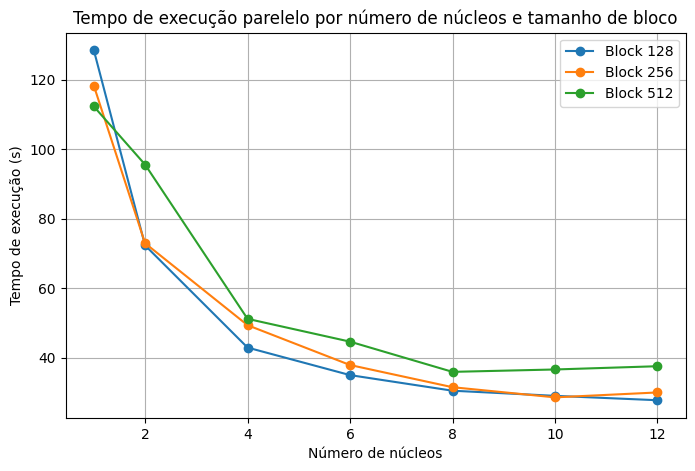

In [52]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["time_seconds"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Tempo de execução (s)")
plt.title("Tempo de execução parelelo por número de núcleos e tamanho de bloco")
plt.legend()
plt.grid(True)
plt.show()


In [62]:
# Tempo linear (base)
T1 = df[df['type'] == 'Linear']['time_seconds'].iloc[0]
T2 = df[(df['type'] == 'Blocked local') & (df['block_size'] == 128)]['time_seconds'].iloc[0]
T3 = df[(df['type'] == 'Blocked local') & (df['block_size'] == 256)]['time_seconds'].iloc[0]
T4 = df[(df['type'] == 'Blocked local') & (df['block_size'] == 512)]['time_seconds'].iloc[0]

print(T1)
print(T2)

# Calcular speedup e eficiência
df_blocked["speedup"] = T2 / df_blocked["time_seconds"]
df_blocked["efficiency"] = df_blocked["speedup"] / df_blocked["num_cores"]

df_blocked

739.0162164000212
128.50263569998788


,time_seconds,num_cores,block_size,type,speedup,efficiency
1,128.502636,1,128,Blocked local,1.000000,1.000000
2,72.352800,2,128,Blocked local,1.776056,0.888028
3,42.954266,4,128,Blocked local,2.991615,0.747904
4,35.033347,6,128,Blocked local,3.668009,0.611335
5,30.545650,8,128,Blocked local,4.206905,0.525863
6,29.067674,10,128,Blocked local,4.420809,0.442081
7,27.808154,12,128,Blocked local,4.621042,0.385087
8,118.307509,1,256,Blocked local,1.086175,1.086175
9,72.965026,2,256,Blocked local,1.761154,0.880577
10,49.395249,4,256,Blocked local,2.601518,0.650380


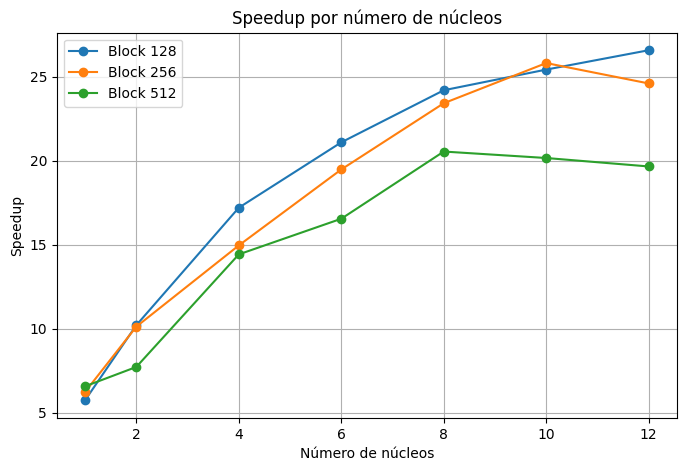

In [47]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.title("Speedup por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()


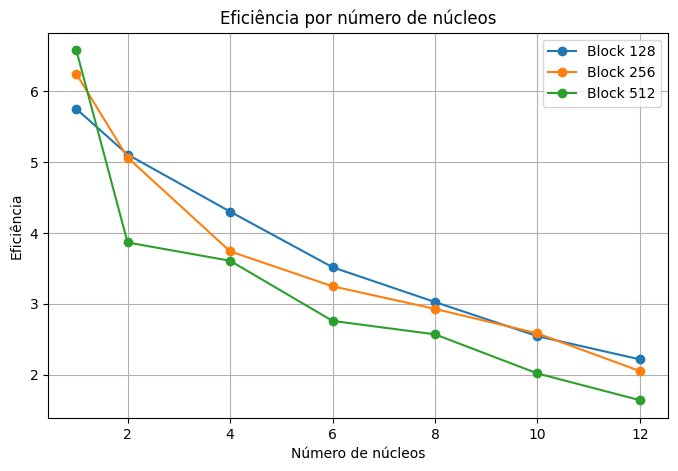

In [48]:
plt.figure(figsize=(8,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["efficiency"], marker='o', label=f"Block {block_size}")
plt.xlabel("Número de núcleos")
plt.ylabel("Eficiência")
plt.title("Eficiência por número de núcleos")
plt.legend()
plt.grid(True)
plt.show()


In [49]:
# Pegar o melhor tempo local (menor tempo entre todos blocos e núcleos)
best_local_time = df_blocked["time_seconds"].min()

# Tempo distribuído
T_dist = df[df['type'] == 'Distributed']['time_seconds'].iloc[0]

# Comparação em gráfico de barras
labels = ["Linear (1 core)", "Melhor local", "Distribuído"]
tempos = [T1, best_local_time, T_dist]

plt.figure(figsize=(6,5))
plt.bar(labels, tempos, color=['gray', 'steelblue', 'green'])
plt.ylabel("Tempo (s)")
plt.title("Comparativo entre linear, local e distribuído")
plt.show()


IndexError: single positional indexer is out-of-bounds

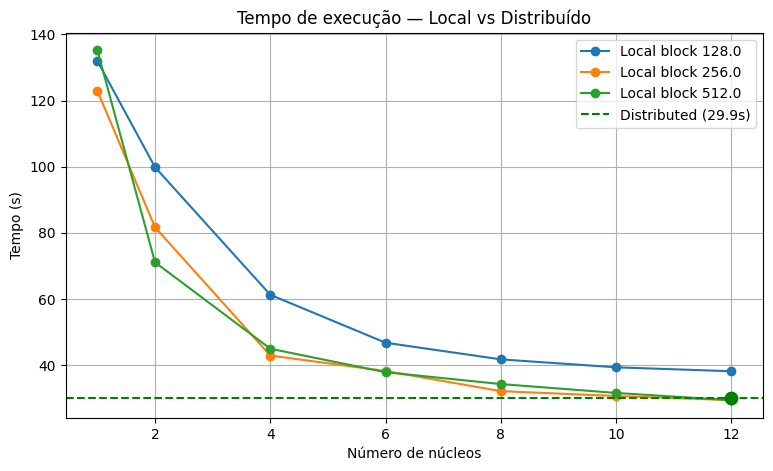

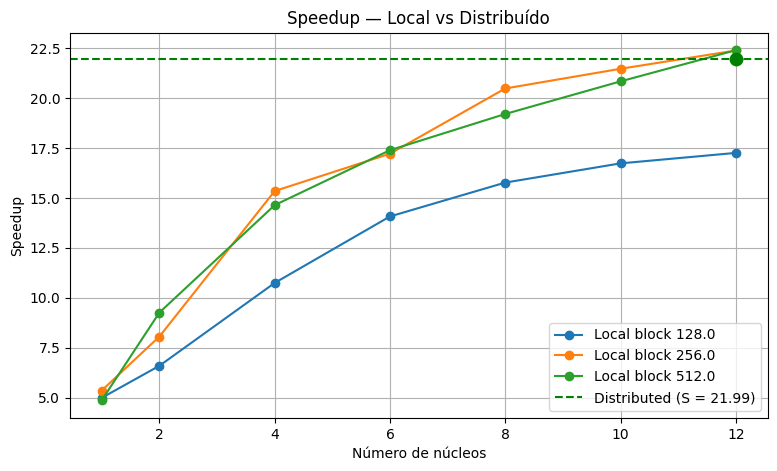

In [ ]:
import json
import pandas as pd
import matplotlib.pyplot as plt

# === 1️⃣ Ler os dados ===
with open(r"matrix_multiplication\data\stats.json", "r") as f:
    data = json.load(f)

records = []
for entry in data:
    for key, value in entry.items():
        value["type"] = key
        records.append(value)

df = pd.DataFrame(records)

# === 2️⃣ Extrair tempos relevantes ===
T_linear = df.loc[df['type'] == 'Linear', 'time_seconds'].iloc[0]
T_distributed = df.loc[df['type'] == 'Distributed', 'time_seconds'].iloc[0]

# Filtrar execuções locais bloqueadas
df_blocked = df[df['type'] == 'Blocked local'].copy()

# Calcular speedup e eficiência relativos ao linear
df_blocked["speedup"] = T_linear / df_blocked["time_seconds"]
df_blocked["efficiency"] = df_blocked["speedup"] / df_blocked["num_cores"]

# === 3️⃣ Criar DataFrame com linha do distribuído ===
distributed_row = pd.DataFrame([{
    "type": "Distributed",
    "time_seconds": T_distributed,
    "num_cores": df_blocked["num_cores"].max(),  # ou outro valor simbólico (ex: 12)
    "block_size": 2048,
    "speedup": T_linear / T_distributed,
    "efficiency": (T_linear / T_distributed) / df_blocked["num_cores"].max()
}])

# Juntar tudo
df_all = pd.concat([df_blocked, distributed_row], ignore_index=True)

# === 4️⃣ Gráfico 1: Tempo comparando local e distribuído ===
plt.figure(figsize=(9,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["time_seconds"], marker='o', label=f"Local block {block_size}")

plt.axhline(T_distributed, color="green", linestyle="--", label=f"Distributed ({T_distributed:.1f}s)")
plt.scatter([12], [T_distributed], color="green", s=80, zorder=5)

plt.title("Tempo de execução — Local vs Distribuído")
plt.xlabel("Número de núcleos")
plt.ylabel("Tempo (s)")
plt.legend()
plt.grid(True)
plt.show()

# === 5️⃣ Gráfico 2: Speedup comparando local e distribuído ===
plt.figure(figsize=(9,5))
for block_size, subdf in df_blocked.groupby("block_size"):
    plt.plot(subdf["num_cores"], subdf["speedup"], marker='o', label=f"Local block {block_size}")

plt.axhline(T_linear / T_distributed, color="green", linestyle="--", label=f"Distributed (S = {T_linear / T_distributed:.2f})")
plt.scatter([12], [T_linear / T_distributed], color="green", s=80, zorder=5)

plt.title("Speedup — Local vs Distribuído")
plt.xlabel("Número de núcleos")
plt.ylabel("Speedup")
plt.legend()
plt.grid(True)
plt.show()


## Cálculo do Speedup

## Cálculo da Eficiência